In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('./Dataset/student_clustering.csv')

df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape: (200, 2)

Columns:
Index(['cgpa', 'iq'], dtype='str')

Data types:
cgpa    float64
iq        int64
dtype: object


In [5]:
X = df.iloc[:, :].values

print("X shape:", X.shape)
print(X[:5])

X shape: (200, 2)
[[  5.13  88.  ]
 [  5.9  113.  ]
 [  8.36  93.  ]
 [  8.27  97.  ]
 [  5.45 110.  ]]


In [6]:
class KMeans:

    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):

        # Step 1: randomly select k data points as initial centroids
        random_index = random.sample(
            range(0, X.shape[0]),
            self.n_clusters
        )

        self.centroids = X[random_index]

        # Repeat the K-Means process
        for i in range(self.max_iter):

            # Step 2 & 3: assign every point to its nearest centroid
            cluster_group = self.assign_clusters(X)

            # Store old centroids
            old_centroids = self.centroids.copy()

            # Step 4: move centroids to the mean of their clusters
            self.centroids = self.move_centroids(
                X,
                cluster_group
            )

            # Step 5: stop if centroids no longer change
            if np.array_equal(old_centroids, self.centroids):
                break

        return cluster_group

    def assign_clusters(self, X):

        cluster_group = []

        for row in X:

            distances = []

            # Calculate distance from current point
            # to every centroid
            for centroid in self.centroids:

                distance = np.sqrt(
                    np.dot(
                        row - centroid,
                        row - centroid
                    )
                )

                distances.append(distance)

            # Find the closest centroid
            min_distance = min(distances)
            index_pos = distances.index(min_distance)

            # Store the cluster number
            cluster_group.append(index_pos)

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):

        new_centroids = []

        # Find the unique cluster numbers
        cluster_type = np.unique(cluster_group)

        for cluster in cluster_type:

            # Select points belonging to this cluster
            cluster_points = X[cluster_group == cluster]

            # Calculate their mean
            cluster_mean = cluster_points.mean(axis=0)

            new_centroids.append(cluster_mean)

        return np.array(new_centroids)

In [7]:
km = KMeans(
    n_clusters=4,
    max_iter=500
)

y_means = km.fit_predict(X)

print("Cluster labels:")
print(y_means)

Cluster labels:
[2 1 2 2 1 0 2 3 1 2 2 1 2 2 0 2 1 2 1 1 2 2 2 2 2 2 2 3 2 0 3 1 3 0 2 2 3
 0 2 1 2 2 2 2 3 3 2 0 3 0 2 2 3 2 3 0 1 3 0 3 0 2 2 3 2 1 2 2 1 2 0 3 2 2
 0 3 1 3 2 2 2 3 1 2 3 2 3 0 3 0 3 3 2 2 2 2 3 2 2 3 1 2 2 3 2 2 2 2 3 3 2
 3 0 1 2 3 2 0 3 2 2 0 2 3 2 2 2 0 2 2 2 1 2 2 1 3 0 2 0 2 2 2 1 2 2 3 2 3
 0 2 3 2 3 3 2 2 1 3 1 2 2 3 0 2 3 2 0 2 2 3 3 1 3 2 2 2 3 0 2 3 3 0 1 0 2
 2 2 2 3 1 2 2 2 2 2 2 3 1 0 3]


In [8]:
unique, counts = np.unique(y_means, return_counts=True)

for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} students")

Cluster 0: 27 students
Cluster 1: 25 students
Cluster 2: 99 students
Cluster 3: 49 students


In [9]:
print("Final centroids:")
print(km.centroids)

Final centroids:
[[  5.97925926 107.74074074]
 [  5.998      111.2       ]
 [  6.57040404  90.55555556]
 [  8.87387755 117.24489796]]


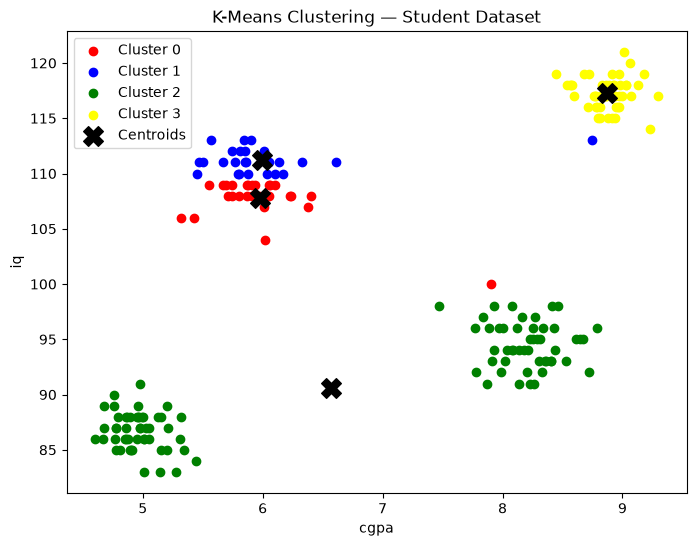

In [10]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y_means == 0, 0],
    X[y_means == 0, 1],
    color='red',
    label='Cluster 0'
)

plt.scatter(
    X[y_means == 1, 0],
    X[y_means == 1, 1],
    color='blue',
    label='Cluster 1'
)

plt.scatter(
    X[y_means == 2, 0],
    X[y_means == 2, 1],
    color='green',
    label='Cluster 2'
)

plt.scatter(
    X[y_means == 3, 0],
    X[y_means == 3, 1],
    color='yellow',
    label='Cluster 3'
)

# Plot the centroids
plt.scatter(
    km.centroids[:, 0],
    km.centroids[:, 1],
    color='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title('K-Means Clustering — Student Dataset')
plt.legend()
plt.show()

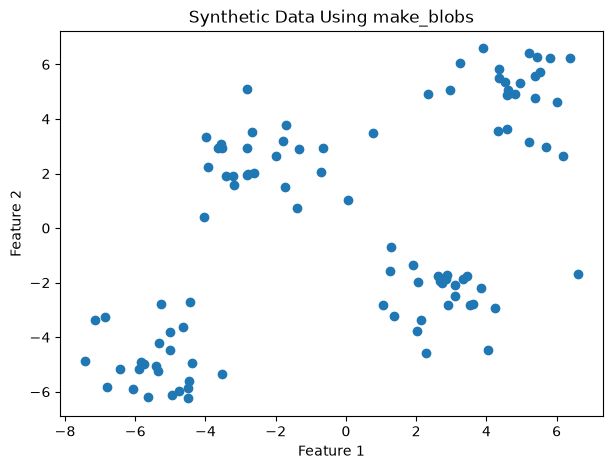

In [11]:
from sklearn.datasets import make_blobs

centroids = [
    (-5, -5),
    (5, 5),
    (-2.5, 2.5),
    (2.5, -2.5)
]

cluster_std = [1, 1, 1, 1]

X_blob, y_blob = make_blobs(
    n_samples=100,
    cluster_std=cluster_std,
    centers=centroids,
    n_features=2,
    random_state=2
)

plt.figure(figsize=(7, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1])
plt.title("Synthetic Data Using make_blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()